In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def get_node_order(G):
    return sorted(G.nodes())


def get_edge_order(G):
    return sorted(G.edges())


def print_basic_info(G):
    print("Nodes:")
    print(get_node_order(G))

    print("\nEdges:")
    print(get_edge_order(G))

    print("\nNumber of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())

In [3]:
def show_adjacency_matrix(G):
    node_order = get_node_order(G)

    adj_matrix = nx.to_numpy_array(
        G,
        nodelist=node_order,
        dtype=int
    )

    print("\nAdjacency Matrix:")
    print(adj_matrix)

    return adj_matrix

In [4]:
def show_adjacency_list(G):
    node_order = get_node_order(G)

    if G.is_directed():
        adj_list = {
            node: sorted(list(G.successors(node)))
            for node in node_order
        }
    else:
        adj_list = {
            node: sorted(list(G.neighbors(node)))
            for node in node_order
        }

    print("\nAdjacency List:")
    for node, neighbors in adj_list.items():
        print(f"{node}: {neighbors}")

    return adj_list

In [5]:
def show_incidence_matrix(G):
    node_order = get_node_order(G)
    edge_order = get_edge_order(G)

    if G.is_directed():
        incidence_matrix = nx.incidence_matrix(
            G,
            nodelist=node_order,
            edgelist=edge_order,
            oriented=True
        ).toarray().astype(int)
    else:
        incidence_matrix = nx.incidence_matrix(
            G,
            nodelist=node_order,
            edgelist=edge_order,
            oriented=False
        ).toarray().astype(int)

    print("\nIncidence Matrix:")
    print(incidence_matrix)

    print("\nIncidence Matrix Column Meaning:")
    for idx, edge in enumerate(edge_order):
        if G.is_directed():
            print(f"Column {idx}: Edge {edge[0]} -> {edge[1]}")
        else:
            print(f"Column {idx}: Edge {edge}")

    return incidence_matrix

In [6]:
def check_undirected_connectivity(G):
    is_connected = nx.is_connected(G)

    print("\nConnectivity Analysis:")
    print("Is connected?", is_connected)

    if is_connected:
        print("Result: The undirected graph is connected.")
    else:
        print("Result: The undirected graph is not connected.")

    print("\nConnected Components:")
    print(list(nx.connected_components(G)))


def check_directed_connectivity(G):
    is_strong = nx.is_strongly_connected(G)
    is_weak = nx.is_weakly_connected(G)

    print("\nConnectivity Analysis:")
    print("Is strongly connected?", is_strong)
    print("Is weakly connected?", is_weak)

    if is_strong:
        print("Result: The directed graph is strongly connected.")
    elif is_weak:
        print("Result: The directed graph is weakly connected but not strongly connected.")
    else:
        print("Result: The directed graph is neither strongly nor weakly connected.")

    print("\nStrongly Connected Components:")
    print(list(nx.strongly_connected_components(G)))

    print("\nWeakly Connected Components:")
    print(list(nx.weakly_connected_components(G)))

In [7]:
def draw_graph(G, title, seed_value=166):
    plt.figure(figsize=(6, 4))

    pos = nx.spring_layout(G, seed=seed_value)

    if G.is_directed():
        nx.draw(
            G,
            pos,
            with_labels=True,
            arrows=True,
            node_color="lightblue",
            node_size=700,
            font_weight="bold",
            arrowsize=20
        )
    else:
        nx.draw(
            G,
            pos,
            with_labels=True,
            node_color="lightpink",
            node_size=700,
            font_weight="bold"
        )

    plt.title(title)
    plt.show()

In [8]:
def analyze_graph(G, graph_name):
    print(graph_name)

    print_basic_info(G)

    show_adjacency_matrix(G)
    show_adjacency_list(G)
    show_incidence_matrix(G)

    if G.is_directed():
        check_directed_connectivity(G)
    else:
        check_undirected_connectivity(G)

    draw_graph(G, graph_name)

Undirected Graphs
Random Undirected Graph 1
Nodes:
[0, 1, 2]

Edges:
[(0, 1), (0, 2), (1, 2)]

Number of nodes: 3
Number of edges: 3

Adjacency Matrix:
[[0 1 1]
 [1 0 1]
 [1 1 0]]

Adjacency List:
0: [1, 2]
1: [0, 2]
2: [0, 1]

Incidence Matrix:
[[1 1 0]
 [1 0 1]
 [0 1 1]]

Incidence Matrix Column Meaning:
Column 0: Edge (0, 1)
Column 1: Edge (0, 2)
Column 2: Edge (1, 2)

Connectivity Analysis:
Is connected? True
Result: The undirected graph is connected.

Connected Components:
[{0, 1, 2}]


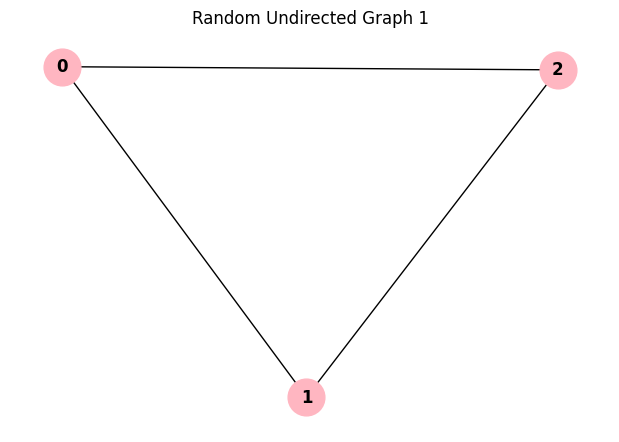

Random Undirected Graph 2
Nodes:
[0, 1, 2, 3]

Edges:
[(0, 1), (0, 2), (0, 3), (2, 3)]

Number of nodes: 4
Number of edges: 4

Adjacency Matrix:
[[0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]]

Adjacency List:
0: [1, 2, 3]
1: [0]
2: [0, 3]
3: [0, 2]

Incidence Matrix:
[[1 1 1 0]
 [1 0 0 0]
 [0 1 0 1]
 [0 0 1 1]]

Incidence Matrix Column Meaning:
Column 0: Edge (0, 1)
Column 1: Edge (0, 2)
Column 2: Edge (0, 3)
Column 3: Edge (2, 3)

Connectivity Analysis:
Is connected? True
Result: The undirected graph is connected.

Connected Components:
[{0, 1, 2, 3}]


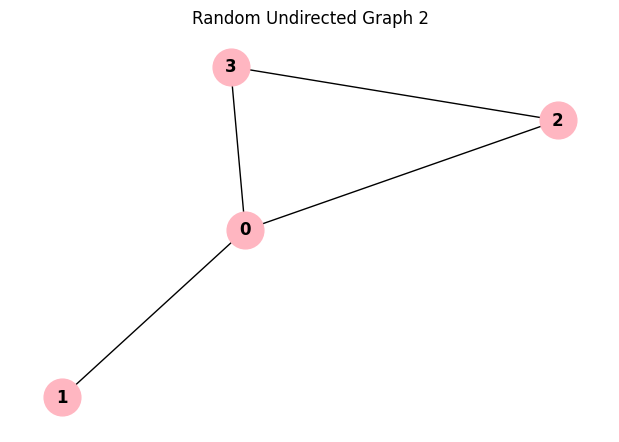

In [9]:
seed_value = 166
random.seed(seed_value)

print("Undirected Graphs")

for i in range(2):
    nodes = random.randint(3, 5)
    edges = random.randint(nodes, nodes * 2)

    G_undirected = nx.gnm_random_graph(
        nodes,
        edges,
        seed=seed_value + i,
        directed=False
    )

    analyze_graph(
        G_undirected,
        f"Random Undirected Graph {i + 1}"
    )

Directed Graphs
Random Directed Graph 1
Nodes:
[0, 1, 2]

Edges:
[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

Number of nodes: 3
Number of edges: 6

Adjacency Matrix:
[[0 1 1]
 [1 0 1]
 [1 1 0]]

Adjacency List:
0: [1, 2]
1: [0, 2]
2: [0, 1]

Incidence Matrix:
[[-1 -1  1  0  1  0]
 [ 1  0 -1 -1  0  1]
 [ 0  1  0  1 -1 -1]]

Incidence Matrix Column Meaning:
Column 0: Edge 0 -> 1
Column 1: Edge 0 -> 2
Column 2: Edge 1 -> 0
Column 3: Edge 1 -> 2
Column 4: Edge 2 -> 0
Column 5: Edge 2 -> 1

Connectivity Analysis:
Is strongly connected? True
Is weakly connected? True
Result: The directed graph is strongly connected.

Strongly Connected Components:
[{0, 1, 2}]

Weakly Connected Components:
[{0, 1, 2}]


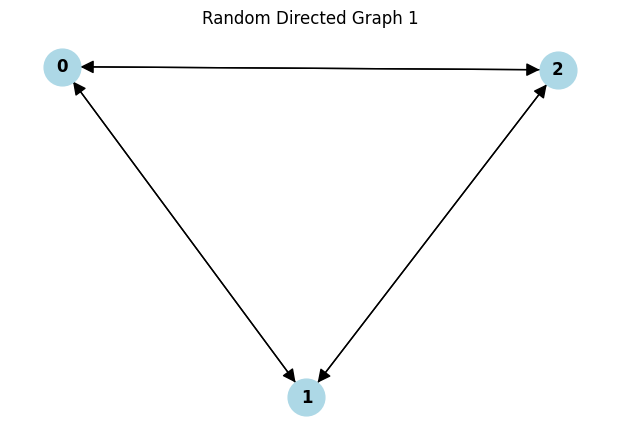

Random Directed Graph 2
Nodes:
[0, 1, 2, 3]

Edges:
[(0, 3), (1, 0), (2, 0), (2, 3)]

Number of nodes: 4
Number of edges: 4

Adjacency Matrix:
[[0 0 0 1]
 [1 0 0 0]
 [1 0 0 1]
 [0 0 0 0]]

Adjacency List:
0: [3]
1: [0]
2: [0, 3]
3: []

Incidence Matrix:
[[-1  1  1  0]
 [ 0 -1  0  0]
 [ 0  0 -1 -1]
 [ 1  0  0  1]]

Incidence Matrix Column Meaning:
Column 0: Edge 0 -> 3
Column 1: Edge 1 -> 0
Column 2: Edge 2 -> 0
Column 3: Edge 2 -> 3

Connectivity Analysis:
Is strongly connected? False
Is weakly connected? True
Result: The directed graph is weakly connected but not strongly connected.

Strongly Connected Components:
[{3}, {0}, {1}, {2}]

Weakly Connected Components:
[{0, 1, 2, 3}]


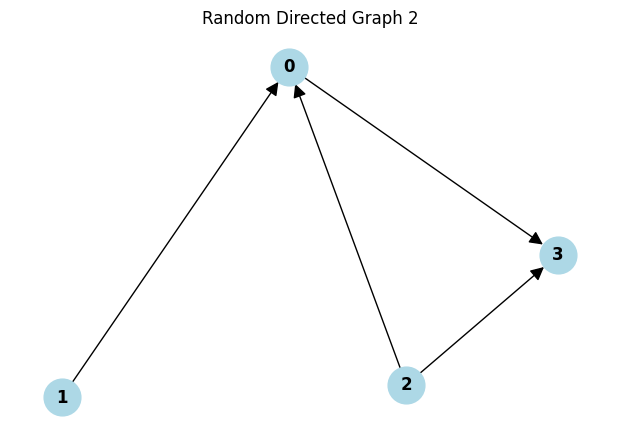

In [10]:
seed_value = 166
random.seed(seed_value)

print("Directed Graphs")

for i in range(2):
    nodes = random.randint(3, 5)
    edges = random.randint(nodes, nodes * 2)

    G_directed = nx.gnm_random_graph(
        nodes,
        edges,
        seed=seed_value + i,
        directed=True
    )

    analyze_graph(
        G_directed,
        f"Random Directed Graph {i + 1}"
    )